In [1]:
# ========== 代码块 0：基础环境与工具函数 ==========
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# （可选）用于 Bootstrap 区间
from tqdm import tqdm
from scipy import sparse

In [2]:
# ========== 全局参数 ==========
RANDOM_STATE = 42
DATA_DIR = "ori_data"
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

In [3]:
# ========== 工具函数 ==========
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def split_X_y(df, target_col, id_col="ID"):
    """分离特征X、标签y（训练集）"""
    y = df[target_col].values
    drop_cols = [target_col]
    if id_col in df.columns:
        drop_cols.append(id_col)
    X = df.drop(columns=drop_cols)
    return X, y

def split_X(df, id_col="ID"):
    """提取特征X（测试集）"""
    drop_cols = []
    if id_col in df.columns:
        drop_cols.append(id_col)
    X = df.drop(columns=drop_cols)
    return X

def build_preprocessor(X: pd.DataFrame):
    """
    统一预处理：缺失值处理 + 类别OneHot
    【关键点】统一Pipeline，避免数据泄漏
    """
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    numeric_tf = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])
    categorical_tf = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_tf, numeric_cols),
            ("cat", categorical_tf, categorical_cols),
        ],
        remainder="drop"
    )
    return preprocessor, numeric_cols, categorical_cols

def get_feature_names(preprocessor, numeric_cols, categorical_cols):
    """获取OneHot后的特征名，用于SHAP表 & PDP说明"""
    feature_names = []
    feature_names.extend(numeric_cols)

    if len(categorical_cols) > 0:
        ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
        ohe_names = ohe.get_feature_names_out(categorical_cols).tolist()
        feature_names.extend(ohe_names)

    return feature_names

def drop_transfer_feature(X: pd.DataFrame):
    """统一去掉迁移特征列"""
    X2 = X.copy()
    for col in ["transfer_rent_pred", "transfer_price_pred"]:
        if col in X2.columns:
            X2 = X2.drop(columns=[col])
    return X2

def export_submission_like_csv(
    model_name: str,
    price_test_ids: np.ndarray,
    rent_test_ids: np.ndarray,
    price_pred: np.ndarray,
    rent_pred: np.ndarray,
    suffix: str = ""   # "" 或 "_noT"
):
    """
    统一输出：按你原先约定，把 Price_test 与 Rent_test 预测拼到一个文件（ID全局唯一）
    输出列名仍为 ["ID","Price"]（与作业/提交格式一致）
    """
    out_df = pd.concat([
        pd.DataFrame({"ID": price_test_ids, "Price": price_pred}),
        pd.DataFrame({"ID": rent_test_ids,  "Price": rent_pred}),
    ], axis=0, ignore_index=True)

    out_path = os.path.join(OUT_DIR, f"{model_name}{suffix}_result.csv")
    out_df.to_csv(out_path, index=False)
    print("✅ 已输出：", out_path, "shape=", out_df.shape)
    return out_path

In [4]:
# ==========================================================
# 统一训练/评估/预测：通用版本（Ridge/RF/MLP 等）
# ==========================================================
def train_eval_predict(
    model_name: str,
    base_model,
    X_train, y_train,
    X_test,
    add_scaler: bool = False,
    do_cv: bool = True,
    cv_splits: int = 5
):
    """
    训练、评估、预测的统一接口（通用）。
    """
    preprocessor, _, _ = build_preprocessor(X_train)

    steps = [("prep", preprocessor)]
    if add_scaler:
        steps.append(("scaler", StandardScaler(with_mean=False)))
    steps.append(("model", base_model))

    pipe = Pipeline(steps=steps)

    # out-of-sample 验证集
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=RANDOM_STATE
    )

    pipe.fit(X_tr, y_tr)
    pred_tr = pipe.predict(X_tr)
    pred_val = pipe.predict(X_val)

    in_rmse = rmse(y_tr, pred_tr)
    oos_rmse = rmse(y_val, pred_val)

    cv_rmse = None
    if do_cv:
        cv = KFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)
        scores = cross_val_score(pipe, X_train, y_train,
                                 scoring="neg_root_mean_squared_error", cv=cv)
        cv_rmse = float(-scores.mean())

    # final fit + test pred
    pipe.fit(X_train, y_train)
    test_pred = pipe.predict(X_test)

    metrics = {
        "model": model_name,
        "in_sample_rmse": in_rmse,
        "out_of_sample_rmse": oos_rmse,
        "cv_rmse": cv_rmse
    }
    return pipe, metrics, test_pred

In [5]:
# ==========================================================
# LightGBM 专用训练：支持 early stopping + Optuna
# ==========================================================
def _safe_import_lightgbm():
    try:
        import lightgbm as lgb
        return lgb
    except Exception as e:
        print("❌ lightgbm 不可用：", e)
        return None

def train_eval_predict_lgb(
    model_name: str,
    lgb_params: dict,
    X_train: pd.DataFrame,
    y_train: np.ndarray,
    X_test: pd.DataFrame,
    do_cv: bool = True,
    cv_splits: int = 5,
    early_stopping_rounds: int = 100
):
    """
    【改动2/3支撑】LightGBM 专用训练：
      - 依旧沿用你的预处理（缺失+OneHot）
      - 使用 early stopping（train/val split）
    """
    lgb = _safe_import_lightgbm()
    if lgb is None:
        raise RuntimeError("lightgbm 不可用，无法训练 LightGBM。")

    preprocessor, _, _ = build_preprocessor(X_train)

    # split for early stopping
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=RANDOM_STATE
    )

    preprocessor.fit(X_tr)
    X_tr_mat = preprocessor.transform(X_tr)
    X_val_mat = preprocessor.transform(X_val)
    X_train_mat_full = preprocessor.transform(X_train)
    X_test_mat = preprocessor.transform(X_test)

    # LGBMRegressor
    model = lgb.LGBMRegressor(**lgb_params)

    # early stopping（sklearn API）
    model.fit(
        X_tr_mat, y_tr,
        eval_set=[(X_val_mat, y_val)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(early_stopping_rounds, verbose=False)]
    )

    pred_tr = model.predict(X_tr_mat)
    pred_val = model.predict(X_val_mat)

    in_rmse = rmse(y_tr, pred_tr)
    oos_rmse = rmse(y_val, pred_val)

    cv_rmse = None
    if do_cv:
        # 为了保持和你原来“pipe + CV”的口径一致，这里做“预处理+模型”的CV
        cv = KFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)
        rmses = []
        for tr_idx, va_idx in cv.split(X_train):
            X_tr2 = X_train.iloc[tr_idx]
            y_tr2 = y_train[tr_idx]
            X_va2 = X_train.iloc[va_idx]
            y_va2 = y_train[va_idx]

            prep2, _, _ = build_preprocessor(X_tr2)
            prep2.fit(X_tr2)
            X_tr2_mat = prep2.transform(X_tr2)
            X_va2_mat = prep2.transform(X_va2)

            m2 = lgb.LGBMRegressor(**lgb_params)
            m2.fit(
                X_tr2_mat, y_tr2,
                eval_set=[(X_va2_mat, y_va2)],
                eval_metric="rmse",
                callbacks=[lgb.early_stopping(early_stopping_rounds, verbose=False)]
            )
            pred_va2 = m2.predict(X_va2_mat)
            rmses.append(rmse(y_va2, pred_va2))
        cv_rmse = float(np.mean(rmses))

    # final fit on full train (for test)
    preprocessor_final, _, _ = build_preprocessor(X_train)
    preprocessor_final.fit(X_train)
    X_train_full_mat = preprocessor_final.transform(X_train)
    X_test_mat = preprocessor_final.transform(X_test)

    model_final = lgb.LGBMRegressor(**lgb_params)
    # 这里用一个小的验证集做 early stopping（防止过拟合），但不改变你总体结构
    X_tr3, X_val3, y_tr3, y_val3 = train_test_split(
        X_train_full_mat, y_train, test_size=0.1, random_state=RANDOM_STATE
    )
    model_final.fit(
        X_tr3, y_tr3,
        eval_set=[(X_val3, y_val3)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(early_stopping_rounds, verbose=False)]
    )

    test_pred = model_final.predict(X_test_mat)

    # 仍然输出一个“管道对象”以便 PDP/SHAP 使用（通过 Pipeline 包装）
    pipe = Pipeline(steps=[
        ("prep", preprocessor_final),
        ("model", model_final)
    ])

    metrics = {
        "model": model_name,
        "in_sample_rmse": in_rmse,
        "out_of_sample_rmse": oos_rmse,
        "cv_rmse": cv_rmse
    }
    return pipe, metrics, test_pred

In [6]:
def optuna_tune_lgb(
    task_name: str,
    X_train: pd.DataFrame,
    y_train: np.ndarray,
    n_trials: int = 25,
    cv_splits: int = 3,
    early_stopping_rounds: int = 100,
    timeout_sec: int = None
):
    """
    【改动3：Optuna 调参】
    Optuna：自动超参数优化框架，核心是不断“试验(trial)→评估→更新搜索方向”来找到更优参数。
    这里用 CV RMSE 作为目标，配合 early stopping 控制训练时间。

    返回：best_params（可直接喂给 LGBMRegressor）
    """
    lgb = _safe_import_lightgbm()
    if lgb is None:
        raise RuntimeError("lightgbm 不可用，无法 Optuna 调参。")

    try:
        import optuna
    except Exception as e:
        print("❌ optuna 不可用：", e)
        raise

    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 1500, 6000),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 31, 255),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 200),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            "random_state": RANDOM_STATE,
            "n_jobs": -1,
        }

        cv = KFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)
        rmses = []
        for tr_idx, va_idx in cv.split(X_train):
            X_tr = X_train.iloc[tr_idx]
            y_tr = y_train[tr_idx]
            X_va = X_train.iloc[va_idx]
            y_va = y_train[va_idx]

            prep, _, _ = build_preprocessor(X_tr)
            prep.fit(X_tr)
            X_tr_mat = prep.transform(X_tr)
            X_va_mat = prep.transform(X_va)

            m = lgb.LGBMRegressor(**params)
            m.fit(
                X_tr_mat, y_tr,
                eval_set=[(X_va_mat, y_va)],
                eval_metric="rmse",
                callbacks=[lgb.early_stopping(early_stopping_rounds, verbose=False)]
            )
            pred_va = m.predict(X_va_mat)
            rmses.append(rmse(y_va, pred_va))

        return float(np.mean(rmses))

    print(f"🔍 Optuna 开始调参：{task_name} | trials={n_trials}, cv={cv_splits}")
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials, timeout=timeout_sec)

    best_params = study.best_params
    # 补齐固定字段
    best_params["random_state"] = RANDOM_STATE
    best_params["n_jobs"] = -1
    print(f"✅ Optuna 完成：{task_name} best_rmse={study.best_value:.4f}")
    print("✅ best_params =", best_params)
    return best_params

In [7]:
# ==========================================================
# XGBoost / CatBoost：新增模型（改动4）
# ==========================================================
def _safe_import_xgboost():
    try:
        import xgboost as xgb
        return xgb
    except Exception as e:
        print("❌ xgboost 不可用：", e)
        return None

def _safe_import_catboost():
    try:
        from catboost import CatBoostRegressor
        return CatBoostRegressor
    except Exception as e:
        print("❌ catboost 不可用：", e)
        return None

In [8]:
# ==========================================================
# 代码块 1：读入数据与基本检查（保持不变）
# ==========================================================
price_train_path = os.path.join(DATA_DIR, "price_train.csv")
price_test_path  = os.path.join(DATA_DIR, "price_test.csv")
rent_train_path  = os.path.join(DATA_DIR, "rent_train.csv")
rent_test_path   = os.path.join(DATA_DIR, "rent_test.csv")

price_train = pd.read_csv(price_train_path)
price_test  = pd.read_csv(price_test_path)
rent_train  = pd.read_csv(rent_train_path)
rent_test   = pd.read_csv(rent_test_path)

print("price_train:", price_train.shape, "columns:", len(price_train.columns))
print("price_test :", price_test.shape,  "columns:", len(price_test.columns))
print("rent_train :", rent_train.shape,  "columns:", len(rent_train.columns))
print("rent_test  :", rent_test.shape,   "columns:", len(rent_test.columns))

assert "Price" in price_train.columns, "price_train 必须包含因变量列 Price"
assert "Rent" in rent_train.columns,   "rent_train 必须包含因变量列 Rent"
assert "ID" in price_test.columns,     "price_test 必须包含 ID"
assert "ID" in rent_test.columns,      "rent_test 必须包含 ID"


price_train: (103871, 77) columns: 77
price_test : (34017, 77) columns: 77
rent_train : (98899, 57) columns: 57
rent_test  : (9773, 57) columns: 57


In [9]:
# ==========================================================
# 代码块 2：跨任务迁移特征（桥接模型）——【改动1：桥接模型改为 LightGBM + OOF风格】
# ==========================================================
def get_common_feature_cols(price_df, rent_df, id_col="ID", price_target="Price", rent_target="Rent"):
    """找出 Price 与 Rent 数据中共同存在的特征列（排除ID和目标）"""
    price_cols = set(price_df.columns) - {id_col, price_target}
    rent_cols  = set(rent_df.columns)  - {id_col, rent_target}
    common = sorted(list(price_cols & rent_cols))
    return common

# 【改动1】OOF风格：用 K 折在“源任务”上训练多个 bridge 子模型（每个用K-1折），
# 然后把这些子模型对“目标训练集”做预测并平均，作为更稳健的“训练侧 transfer 特征”
def oof_style_predict_from_source(
    X_source: pd.DataFrame,
    y_source: np.ndarray,
    X_target_train: pd.DataFrame,
    X_target_test: pd.DataFrame,
    build_model_fn,
    n_splits: int = 5
):
    """
    返回：
      - target_train_pred_oof_style：训练侧 transfer（用多个子模型平均，模拟“OOF风格更稳健”）
      - target_test_pred_fullfit：测试侧 transfer（用全量source fit后预测，提升稳定性）
    """
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    # 训练侧：用多个子模型平均（OOF风格）
    preds_train = []
    for tr_idx, _ in cv.split(X_source):
        X_tr = X_source.iloc[tr_idx]
        y_tr = y_source[tr_idx]

        pre, _, _ = build_preprocessor(X_tr)
        pre.fit(X_tr)

        X_tr_mat = pre.transform(X_tr)
        X_tgt_train_mat = pre.transform(X_target_train)

        model = build_model_fn()
        model.fit(X_tr_mat, y_tr)
        preds_train.append(model.predict(X_tgt_train_mat))

    target_train_pred_oof_style = np.mean(np.vstack(preds_train), axis=0)

    # 测试侧：全量 fit 后预测（更接近“上线”用法）
    pre_full, _, _ = build_preprocessor(X_source)
    pre_full.fit(X_source)
    X_src_full_mat = pre_full.transform(X_source)
    X_tgt_test_mat = pre_full.transform(X_target_test)

    model_full = build_model_fn()
    model_full.fit(X_src_full_mat, y_source)
    target_test_pred_fullfit = model_full.predict(X_tgt_test_mat)

    return target_train_pred_oof_style, target_test_pred_fullfit

In [10]:
common_cols = get_common_feature_cols(price_train, rent_train)
print("共同特征列数量 =", len(common_cols))
if len(common_cols) > 0:
    print("共同特征示例（前10个）:", common_cols[:10])

MIN_COMMON = 3

共同特征列数量 = 44
共同特征示例（前10个）: ['coord_x', 'coord_y', 'lat', 'lon', '交易距今', '区县', '卫数', '厅数', '厨房数', '向东']


In [11]:
# 【改动1】桥接模型：从 RF -> LightGBM
lgb = _safe_import_lightgbm()
if lgb is None:
    raise RuntimeError("lightgbm 不可用，但你要求桥接模型用 LGB。请先安装 lightgbm。")

bridge_lgb_params = dict(
    n_estimators=1200,
    learning_rate=0.03,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

def build_bridge_lgb():
    return lgb.LGBMRegressor(**bridge_lgb_params)

In [12]:
# --- Rent -> Price 迁移特征：transfer_rent_pred ---
if len(common_cols) >= MIN_COMMON:
    X_rent_common = rent_train[common_cols].copy()
    y_rent = rent_train["Rent"].values

    # 【改动1】训练侧：OOF风格（多子模型平均）；测试侧：全量fit预测
    price_train_transfer, price_test_transfer = oof_style_predict_from_source(
        X_source=X_rent_common,
        y_source=y_rent,
        X_target_train=price_train[common_cols].copy(),
        X_target_test=price_test[common_cols].copy(),
        build_model_fn=build_bridge_lgb,
        n_splits=5
    )

    price_train["transfer_rent_pred"] = price_train_transfer
    price_test["transfer_rent_pred"]  = price_test_transfer
    print("✅【改动1】已为 Price 数据加入迁移特征 transfer_rent_pred（桥接=LGB，train=OOF风格，test=全量fit预测）")
else:
    global_rent_mean = float(rent_train["Rent"].mean())
    price_train["transfer_rent_pred"] = global_rent_mean
    price_test["transfer_rent_pred"]  = global_rent_mean
    print("⚠️ 共同特征过少：使用全局均值作为 transfer_rent_pred")

✅【改动1】已为 Price 数据加入迁移特征 transfer_rent_pred（桥接=LGB，train=OOF风格，test=全量fit预测）


In [13]:
# --- Price -> Rent 迁移特征：transfer_price_pred ---
if len(common_cols) >= MIN_COMMON:
    X_price_common = price_train[common_cols].copy()
    y_price = price_train["Price"].values

    # 【改动1】训练侧：OOF风格；测试侧：全量fit预测
    rent_train_transfer, rent_test_transfer = oof_style_predict_from_source(
        X_source=X_price_common,
        y_source=y_price,
        X_target_train=rent_train[common_cols].copy(),
        X_target_test=rent_test[common_cols].copy(),
        build_model_fn=build_bridge_lgb,
        n_splits=5
    )

    rent_train["transfer_price_pred"] = rent_train_transfer
    rent_test["transfer_price_pred"]  = rent_test_transfer
    print("✅【改动1】已为 Rent 数据加入迁移特征 transfer_price_pred（桥接=LGB，train=OOF风格，test=全量fit预测）")
else:
    global_price_mean = float(price_train["Price"].mean())
    rent_train["transfer_price_pred"] = global_price_mean
    rent_test["transfer_price_pred"]  = global_price_mean
    print("⚠️ 共同特征过少：使用全局均值作为 transfer_price_pred")

✅【改动1】已为 Rent 数据加入迁移特征 transfer_price_pred（桥接=LGB，train=OOF风格，test=全量fit预测）


In [14]:
# ==========================================================
# 代码块 3：准备训练数据（保持结构不变）
# ==========================================================

In [15]:
# 带迁移特征
X_price_train_T, y_price_train = split_X_y(price_train, "Price")
X_price_test_T = split_X(price_test)

X_rent_train_T, y_rent_train = split_X_y(rent_train, "Rent")
X_rent_test_T = split_X(rent_test)


In [16]:
# 不带迁移特征（noT）
X_price_train_noT = drop_transfer_feature(X_price_train_T)
X_price_test_noT  = drop_transfer_feature(X_price_test_T)

X_rent_train_noT = drop_transfer_feature(X_rent_train_T)
X_rent_test_noT  = drop_transfer_feature(X_rent_test_T)

In [17]:
# ==========================================================
# 代码块 4：Midterm Linear Model（Ridge）——【同一处输出 T 与 noT 两份结果】
# ==========================================================
ridge_alpha = 10.0

In [18]:
# ---- Ridge (T) ----
ridge_price_pipe_T, ridge_price_metrics_T, ridge_price_pred_T = train_eval_predict(
    model_name="Midterm_Linear_Ridge_Price",
    base_model=Ridge(alpha=ridge_alpha, random_state=RANDOM_STATE),
    X_train=X_price_train_T, y_train=y_price_train,
    X_test=X_price_test_T,
    add_scaler=True,
    do_cv=True
)

In [19]:
ridge_rent_pipe_T, ridge_rent_metrics_T, ridge_rent_pred_T = train_eval_predict(
    model_name="Midterm_Linear_Ridge_Rent",
    base_model=Ridge(alpha=ridge_alpha, random_state=RANDOM_STATE),
    X_train=X_rent_train_T, y_train=y_rent_train,
    X_test=X_rent_test_T,
    add_scaler=True,
    do_cv=True
)

In [20]:

print(ridge_price_metrics_T)
print(ridge_rent_metrics_T)

{'model': 'Midterm_Linear_Ridge_Price', 'in_sample_rmse': 0.06872322785937221, 'out_of_sample_rmse': 0.06980508238117727, 'cv_rmse': 0.06899539945791625}
{'model': 'Midterm_Linear_Ridge_Rent', 'in_sample_rmse': 0.03722697336277546, 'out_of_sample_rmse': 0.03741025927542535, 'cv_rmse': 0.037299906521272824}


In [21]:
export_submission_like_csv(
    model_name="MidtermLinearRidge",
    price_test_ids=price_test["ID"].values,
    rent_test_ids=rent_test["ID"].values,
    price_pred=ridge_price_pred_T,
    rent_pred=ridge_rent_pred_T,
    suffix=""
)

✅ 已输出： outputs/MidtermLinearRidge_result.csv shape= (43790, 2)


'outputs/MidtermLinearRidge_result.csv'

In [22]:
# ---- Ridge (noT) ----
ridge_price_pipe_noT, ridge_price_metrics_noT, ridge_price_pred_noT = train_eval_predict(
    model_name="Midterm_Linear_Ridge_Price_noT",
    base_model=Ridge(alpha=ridge_alpha, random_state=RANDOM_STATE),
    X_train=X_price_train_noT, y_train=y_price_train,
    X_test=X_price_test_noT,
    add_scaler=True,
    do_cv=True
)


In [23]:
ridge_rent_pipe_noT, ridge_rent_metrics_noT, ridge_rent_pred_noT = train_eval_predict(
    model_name="Midterm_Linear_Ridge_Rent_noT",
    base_model=Ridge(alpha=ridge_alpha, random_state=RANDOM_STATE),
    X_train=X_rent_train_noT, y_train=y_rent_train,
    X_test=X_rent_test_noT,
    add_scaler=True,
    do_cv=True
)

In [24]:
export_submission_like_csv(
    model_name="MidtermLinearRidge",
    price_test_ids=price_test["ID"].values,
    rent_test_ids=rent_test["ID"].values,
    price_pred=ridge_price_pred_noT,
    rent_pred=ridge_rent_pred_noT,
    suffix="_noT"
)

✅ 已输出： outputs/MidtermLinearRidge_noT_result.csv shape= (43790, 2)


'outputs/MidtermLinearRidge_noT_result.csv'

In [25]:
# ==========================================================
# 代码块 5：Random Forest（集成）——【同一处输出 T 与 noT 两份结果】
# ==========================================================
rf_params = dict(
    n_estimators=800,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    max_depth=None,
    min_samples_leaf=2
)

In [26]:
# ---- RF (T) ----
rf_price_pipe_T, rf_price_metrics_T, rf_price_pred_T = train_eval_predict(
    model_name="RF_Price",
    base_model=RandomForestRegressor(**rf_params),
    X_train=X_price_train_T, y_train=y_price_train,
    X_test=X_price_test_T,
    add_scaler=False,
    do_cv=True
)

In [27]:
rf_rent_pipe_T, rf_rent_metrics_T, rf_rent_pred_T = train_eval_predict(
    model_name="RF_Rent",
    base_model=RandomForestRegressor(**rf_params),
    X_train=X_rent_train_T, y_train=y_rent_train,
    X_test=X_rent_test_T,
    add_scaler=False,
    do_cv=True
)

In [28]:
print(rf_price_metrics_T)
print(rf_rent_metrics_T)

{'model': 'RF_Price', 'in_sample_rmse': 0.016816014246341045, 'out_of_sample_rmse': 0.038335519931726535, 'cv_rmse': 0.03746237600725115}
{'model': 'RF_Rent', 'in_sample_rmse': 0.010847720697576647, 'out_of_sample_rmse': 0.02291865795586382, 'cv_rmse': 0.023051691443372723}


In [29]:
export_submission_like_csv(
    model_name="RandomForest",
    price_test_ids=price_test["ID"].values,
    rent_test_ids=rent_test["ID"].values,
    price_pred=rf_price_pred_T,
    rent_pred=rf_rent_pred_T,
    suffix=""
)

✅ 已输出： outputs/RandomForest_result.csv shape= (43790, 2)


'outputs/RandomForest_result.csv'

In [30]:
# ---- RF (noT) ----
rf_price_pipe_noT, rf_price_metrics_noT, rf_price_pred_noT = train_eval_predict(
    model_name="RF_Price_noT",
    base_model=RandomForestRegressor(**rf_params),
    X_train=X_price_train_noT, y_train=y_price_train,
    X_test=X_price_test_noT,
    add_scaler=False,
    do_cv=True
)


In [31]:
rf_rent_pipe_noT, rf_rent_metrics_noT, rf_rent_pred_noT = train_eval_predict(
    model_name="RF_Rent_noT",
    base_model=RandomForestRegressor(**rf_params),
    X_train=X_rent_train_noT, y_train=y_rent_train,
    X_test=X_rent_test_noT,
    add_scaler=False,
    do_cv=True
)

In [32]:
export_submission_like_csv(
    model_name="RandomForest",
    price_test_ids=price_test["ID"].values,
    rent_test_ids=rent_test["ID"].values,
    price_pred=rf_price_pred_noT,
    rent_pred=rf_rent_pred_noT,
    suffix="_noT"
)

✅ 已输出： outputs/RandomForest_noT_result.csv shape= (43790, 2)


'outputs/RandomForest_noT_result.csv'

In [33]:
# ==========================================================
# 代码块 6：ANN（MLPRegressor）——【同一处输出 T 与 noT 两份结果】
# ==========================================================
ann_params = dict(
    hidden_layer_sizes=(256, 128),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=256,
    learning_rate_init=1e-3,
    max_iter=200,
    random_state=RANDOM_STATE,
    early_stopping=True,
    n_iter_no_change=10
)

In [34]:
# ---- ANN (T) ----
ann_price_pipe_T, ann_price_metrics_T, ann_price_pred_T = train_eval_predict(
    model_name="ANN_Price",
    base_model=MLPRegressor(**ann_params),
    X_train=X_price_train_T, y_train=y_price_train,
    X_test=X_price_test_T,
    add_scaler=True,
    do_cv=True
)

In [35]:
ann_rent_pipe_T, ann_rent_metrics_T, ann_rent_pred_T = train_eval_predict(
    model_name="ANN_Rent",
    base_model=MLPRegressor(**ann_params),
    X_train=X_rent_train_T, y_train=y_rent_train,
    X_test=X_rent_test_T,
    add_scaler=True,
    do_cv=True
)

In [36]:
print(ann_price_metrics_T)
print(ann_rent_metrics_T)

{'model': 'ANN_Price', 'in_sample_rmse': 0.14973717282987653, 'out_of_sample_rmse': 0.1513375912599225, 'cv_rmse': 0.14575632865298999}
{'model': 'ANN_Rent', 'in_sample_rmse': 0.13758743882409444, 'out_of_sample_rmse': 0.13766515626497244, 'cv_rmse': 0.16817659757877226}


In [37]:
export_submission_like_csv(
    model_name="ANN",
    price_test_ids=price_test["ID"].values,
    rent_test_ids=rent_test["ID"].values,
    price_pred=ann_price_pred_T,
    rent_pred=ann_rent_pred_T,
    suffix=""
)


✅ 已输出： outputs/ANN_result.csv shape= (43790, 2)


'outputs/ANN_result.csv'

In [38]:
# ---- ANN (noT) ----
ann_price_pipe_noT, ann_price_metrics_noT, ann_price_pred_noT = train_eval_predict(
    model_name="ANN_Price_noT",
    base_model=MLPRegressor(**ann_params),
    X_train=X_price_train_noT, y_train=y_price_train,
    X_test=X_price_test_noT,
    add_scaler=True,
    do_cv=True
)


In [ ]:
print(111)

In [39]:
ann_rent_pipe_noT, ann_rent_metrics_noT, ann_rent_pred_noT = train_eval_predict(
    model_name="ANN_Rent_noT",
    base_model=MLPRegressor(**ann_params),
    X_train=X_rent_train_noT, y_train=y_rent_train,
    X_test=X_rent_test_noT,
    add_scaler=True,
    do_cv=True
)

In [40]:
export_submission_like_csv(
    model_name="ANN",
    price_test_ids=price_test["ID"].values,
    rent_test_ids=rent_test["ID"].values,
    price_pred=ann_price_pred_noT,
    rent_pred=ann_rent_pred_noT,
    suffix="_noT"
)


✅ 已输出： outputs/ANN_noT_result.csv shape= (43790, 2)


'outputs/ANN_noT_result.csv'

In [41]:
# ==========================================================
# 代码块 7：Best Model（LightGBM）——【改动3：Optuna 调参 + early stopping】
# 同一处输出 T 与 noT 两份结果
# ==========================================================
# 先给一个默认参数（若不跑Optuna也可用）
default_lgb_params = dict(
    n_estimators=4000,
    learning_rate=0.03,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)


In [44]:
# 【改动3】Optuna：分别对 Price / Rent 调参（可根据算力改 n_trials）
try:
    best_lgb_params_price = optuna_tune_lgb(
        task_name="LGB_Tune_Price",
        X_train=X_price_train_T,
        y_train=y_price_train,
        n_trials=25,          # 你可调小（如 15）来省时间
        cv_splits=3,          # 你可调小（如 2）来省时间
        early_stopping_rounds=100
    )
except Exception as e:
    print("⚠️ Optuna 调参（Price）失败，回退默认参数。原因：", e)
    best_lgb_params_price = default_lgb_params.copy()

[I 2025-12-23 11:16:16,566] A new study created in memory with name: no-name-7e71b47e-933d-44f7-b716-821d4e01ac62


🔍 Optuna 开始调参：LGB_Tune_Price | trials=25, cv=3


[I 2025-12-23 11:18:34,254] Trial 0 finished with value: 0.03367466751588862 and parameters: {'n_estimators': 2343, 'learning_rate': 0.034054804222382336, 'num_leaves': 216, 'min_child_samples': 101, 'subsample': 0.9609971282178205, 'colsample_bytree': 0.9773415942736537, 'reg_alpha': 2.456600849245275e-06, 'reg_lambda': 0.0002958789905384998}. Best is trial 0 with value: 0.03367466751588862.
[I 2025-12-23 11:18:53,049] Trial 1 finished with value: 0.04104135642445549 and parameters: {'n_estimators': 2226, 'learning_rate': 0.04776997479852588, 'num_leaves': 108, 'min_child_samples': 120, 'subsample': 0.9626423281612848, 'colsample_bytree': 0.8203551952690303, 'reg_alpha': 6.373698346949153, 'reg_lambda': 0.3733659373030218}. Best is trial 0 with value: 0.03367466751588862.
[I 2025-12-23 11:20:41,860] Trial 2 finished with value: 0.0336970364230846 and parameters: {'n_estimators': 5111, 'learning_rate': 0.06133201475105611, 'num_leaves': 233, 'min_child_samples': 49, 'subsample': 0.8500

✅ Optuna 完成：LGB_Tune_Price best_rmse=0.0327
✅ best_params = {'n_estimators': 4842, 'learning_rate': 0.048366478542384884, 'num_leaves': 98, 'min_child_samples': 17, 'subsample': 0.7203222800661788, 'colsample_bytree': 0.8189908054577337, 'reg_alpha': 0.13424738785286233, 'reg_lambda': 9.095019994067645e-08, 'random_state': 42, 'n_jobs': -1}


In [45]:

try:
    best_lgb_params_rent = optuna_tune_lgb(
        task_name="LGB_Tune_Rent",
        X_train=X_rent_train_T,
        y_train=y_rent_train,
        n_trials=25,
        cv_splits=3,
        early_stopping_rounds=100
    )
except Exception as e:
    print("⚠️ Optuna 调参（Rent）失败，回退默认参数。原因：", e)
    best_lgb_params_rent = default_lgb_params.copy()


[I 2025-12-23 12:02:14,352] A new study created in memory with name: no-name-80400e53-269c-4eb6-8917-c53b9b8bcdc5


🔍 Optuna 开始调参：LGB_Tune_Rent | trials=25, cv=3


[I 2025-12-23 12:04:08,289] Trial 0 finished with value: 0.021649778158526266 and parameters: {'n_estimators': 2958, 'learning_rate': 0.01988095953169566, 'num_leaves': 223, 'min_child_samples': 41, 'subsample': 0.647713292113152, 'colsample_bytree': 0.6490092648972012, 'reg_alpha': 0.09484665938982442, 'reg_lambda': 2.111277333670754}. Best is trial 0 with value: 0.021649778158526266.
[I 2025-12-23 12:04:30,749] Trial 1 finished with value: 0.024283926223304397 and parameters: {'n_estimators': 2631, 'learning_rate': 0.027189610492633468, 'num_leaves': 109, 'min_child_samples': 197, 'subsample': 0.7109796970938937, 'colsample_bytree': 0.8211434047611686, 'reg_alpha': 2.7550734978817104, 'reg_lambda': 1.0755506866015078e-07}. Best is trial 0 with value: 0.021649778158526266.
[I 2025-12-23 12:06:13,077] Trial 2 finished with value: 0.021999295282191852 and parameters: {'n_estimators': 5596, 'learning_rate': 0.02036462337249806, 'num_leaves': 152, 'min_child_samples': 117, 'subsample': 0.

✅ Optuna 完成：LGB_Tune_Rent best_rmse=0.0216
✅ best_params = {'n_estimators': 5116, 'learning_rate': 0.012812350159625799, 'num_leaves': 170, 'min_child_samples': 28, 'subsample': 0.7038569093440081, 'colsample_bytree': 0.6482750144927482, 'reg_alpha': 0.00035242063775976594, 'reg_lambda': 1.7508744393008637e-06, 'random_state': 42, 'n_jobs': -1}


In [46]:
# ---- LGB (T) ----
best_price_pipe_T, best_price_metrics_T, best_price_pred_T = train_eval_predict_lgb(
    model_name="LGB_Price",
    lgb_params=best_lgb_params_price,
    X_train=X_price_train_T, y_train=y_price_train,
    X_test=X_price_test_T,
    do_cv=True,
    cv_splits=5,
    early_stopping_rounds=100
)

In [47]:
best_rent_pipe_T, best_rent_metrics_T, best_rent_pred_T = train_eval_predict_lgb(
    model_name="LGB_Rent",
    lgb_params=best_lgb_params_rent,
    X_train=X_rent_train_T, y_train=y_rent_train,
    X_test=X_rent_test_T,
    do_cv=True,
    cv_splits=5,
    early_stopping_rounds=100
)


In [48]:
print(best_price_metrics_T)
print(best_rent_metrics_T)

{'model': 'LGB_Price', 'in_sample_rmse': 0.010891090323806217, 'out_of_sample_rmse': 0.03233920416478374, 'cv_rmse': 0.03193629112607158}
{'model': 'LGB_Rent', 'in_sample_rmse': 0.011685423997253225, 'out_of_sample_rmse': 0.02126660005905927, 'cv_rmse': 0.021339950835994444}


In [49]:
export_submission_like_csv(
    model_name="BestModel_LightGBM",
    price_test_ids=price_test["ID"].values,
    rent_test_ids=rent_test["ID"].values,
    price_pred=best_price_pred_T,
    rent_pred=best_rent_pred_T,
    suffix=""
)


✅ 已输出： outputs/BestModel_LightGBM_result.csv shape= (43790, 2)


'outputs/BestModel_LightGBM_result.csv'

In [50]:
# ---- LGB (noT) ----
best_price_pipe_noT, best_price_metrics_noT, best_price_pred_noT = train_eval_predict_lgb(
    model_name="LGB_Price_noT",
    lgb_params=best_lgb_params_price,
    X_train=X_price_train_noT, y_train=y_price_train,
    X_test=X_price_test_noT,
    do_cv=True,
    cv_splits=5,
    early_stopping_rounds=100
)

In [51]:
best_rent_pipe_noT, best_rent_metrics_noT, best_rent_pred_noT = train_eval_predict_lgb(
    model_name="LGB_Rent_noT",
    lgb_params=best_lgb_params_rent,
    X_train=X_rent_train_noT, y_train=y_rent_train,
    X_test=X_rent_test_noT,
    do_cv=True,
    cv_splits=5,
    early_stopping_rounds=100
)


In [52]:
export_submission_like_csv(
    model_name="BestModel_LightGBM",
    price_test_ids=price_test["ID"].values,
    rent_test_ids=rent_test["ID"].values,
    price_pred=best_price_pred_noT,
    rent_pred=best_rent_pred_noT,
    suffix="_noT"
)


✅ 已输出： outputs/BestModel_LightGBM_noT_result.csv shape= (43790, 2)


'outputs/BestModel_LightGBM_noT_result.csv'

In [53]:
# ==========================================================
# 代码块 8：新增模型 XGBoost / CatBoost（改动4）
# 同一处输出 T 与 noT 两份结果
# ==========================================================
xgb = _safe_import_xgboost()
CatBoostRegressor = _safe_import_catboost()

In [54]:
# ---- XGBoost ----
xgb_price_pred_T = xgb_rent_pred_T = None
xgb_price_pred_noT = xgb_rent_pred_noT = None
xgb_price_metrics_T = xgb_rent_metrics_T = None
xgb_price_metrics_noT = xgb_rent_metrics_noT = None

In [55]:
if xgb is not None:
    xgb_params = dict(
        n_estimators=5000,
        learning_rate=0.03,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    # XGB 用 sklearn 接口（配合你的预处理）
    xgb_price_pipe_T, xgb_price_metrics_T, xgb_price_pred_T = train_eval_predict(
        model_name="XGB_Price",
        base_model=xgb.XGBRegressor(**xgb_params, objective="reg:squarederror"),
        X_train=X_price_train_T, y_train=y_price_train,
        X_test=X_price_test_T,
        add_scaler=False,
        do_cv=True
    )
    xgb_rent_pipe_T, xgb_rent_metrics_T, xgb_rent_pred_T = train_eval_predict(
        model_name="XGB_Rent",
        base_model=xgb.XGBRegressor(**xgb_params, objective="reg:squarederror"),
        X_train=X_rent_train_T, y_train=y_rent_train,
        X_test=X_rent_test_T,
        add_scaler=False,
        do_cv=True
    )

    export_submission_like_csv(
        model_name="XGBoost",
        price_test_ids=price_test["ID"].values,
        rent_test_ids=rent_test["ID"].values,
        price_pred=xgb_price_pred_T,
        rent_pred=xgb_rent_pred_T,
        suffix=""
    )

    xgb_price_pipe_noT, xgb_price_metrics_noT, xgb_price_pred_noT = train_eval_predict(
        model_name="XGB_Price_noT",
        base_model=xgb.XGBRegressor(**xgb_params, objective="reg:squarederror"),
        X_train=X_price_train_noT, y_train=y_price_train,
        X_test=X_price_test_noT,
        add_scaler=False,
        do_cv=True
    )
    xgb_rent_pipe_noT, xgb_rent_metrics_noT, xgb_rent_pred_noT = train_eval_predict(
        model_name="XGB_Rent_noT",
        base_model=xgb.XGBRegressor(**xgb_params, objective="reg:squarederror"),
        X_train=X_rent_train_noT, y_train=y_rent_train,
        X_test=X_rent_test_noT,
        add_scaler=False,
        do_cv=True
    )

    export_submission_like_csv(
        model_name="XGBoost",
        price_test_ids=price_test["ID"].values,
        rent_test_ids=rent_test["ID"].values,
        price_pred=xgb_price_pred_noT,
        rent_pred=xgb_rent_pred_noT,
        suffix="_noT"
    )

else:
    print("⚠️ 跳过 XGBoost（未安装/不可用）。")

✅ 已输出： outputs/XGBoost_result.csv shape= (43790, 2)
✅ 已输出： outputs/XGBoost_noT_result.csv shape= (43790, 2)


In [56]:
# ---- CatBoost ----
cat_price_pred_T = cat_rent_pred_T = None
cat_price_pred_noT = cat_rent_pred_noT = None
cat_price_metrics_T = cat_rent_metrics_T = None
cat_price_metrics_noT = cat_rent_metrics_noT = None

In [57]:
if CatBoostRegressor is not None:
    # 注意：你这里已经做 OneHot 了，所以 CatBoost 当作普通回归器用即可（不走原生类别处理）
    cat_params = dict(
        iterations=6000,
        learning_rate=0.03,
        depth=8,
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False
    )

    cat_price_pipe_T, cat_price_metrics_T, cat_price_pred_T = train_eval_predict(
        model_name="CAT_Price",
        base_model=CatBoostRegressor(**cat_params),
        X_train=X_price_train_T, y_train=y_price_train,
        X_test=X_price_test_T,
        add_scaler=False,
        do_cv=True
    )
    cat_rent_pipe_T, cat_rent_metrics_T, cat_rent_pred_T = train_eval_predict(
        model_name="CAT_Rent",
        base_model=CatBoostRegressor(**cat_params),
        X_train=X_rent_train_T, y_train=y_rent_train,
        X_test=X_rent_test_T,
        add_scaler=False,
        do_cv=True
    )

    export_submission_like_csv(
        model_name="CatBoost",
        price_test_ids=price_test["ID"].values,
        rent_test_ids=rent_test["ID"].values,
        price_pred=cat_price_pred_T,
        rent_pred=cat_rent_pred_T,
        suffix=""
    )

    cat_price_pipe_noT, cat_price_metrics_noT, cat_price_pred_noT = train_eval_predict(
        model_name="CAT_Price_noT",
        base_model=CatBoostRegressor(**cat_params),
        X_train=X_price_train_noT, y_train=y_price_train,
        X_test=X_price_test_noT,
        add_scaler=False,
        do_cv=True
    )
    cat_rent_pipe_noT, cat_rent_metrics_noT, cat_rent_pred_noT = train_eval_predict(
        model_name="CAT_Rent_noT",
        base_model=CatBoostRegressor(**cat_params),
        X_train=X_rent_train_noT, y_train=y_rent_train,
        X_test=X_rent_test_noT,
        add_scaler=False,
        do_cv=True
    )

    export_submission_like_csv(
        model_name="CatBoost",
        price_test_ids=price_test["ID"].values,
        rent_test_ids=rent_test["ID"].values,
        price_pred=cat_price_pred_noT,
        rent_pred=cat_rent_pred_noT,
        suffix="_noT"
    )

else:
    print("⚠️ 跳过 CatBoost（未安装/不可用）。")

✅ 已输出： outputs/CatBoost_result.csv shape= (43790, 2)
✅ 已输出： outputs/CatBoost_noT_result.csv shape= (43790, 2)


In [58]:
# ==========================================================
# 代码块 9：汇总指标表（保持你原结构，但扩展到更多模型）
# ==========================================================
rows = []

def _add_row(model_label, pm, rm):
    rows.append({
        "Model": model_label,
        "Price_in_rmse": pm["in_sample_rmse"],
        "Price_oos_rmse": pm["out_of_sample_rmse"],
        "Price_cv_rmse": pm["cv_rmse"],
        "Rent_in_rmse": rm["in_sample_rmse"],
        "Rent_oos_rmse": rm["out_of_sample_rmse"],
        "Rent_cv_rmse": rm["cv_rmse"],
    })

In [59]:
# 迁移版（主对比）
_add_row("Midterm Linear Model (Ridge) [T]", ridge_price_metrics_T, ridge_rent_metrics_T)
_add_row("Random Forest [T]", rf_price_metrics_T, rf_rent_metrics_T)
_add_row("ANN (MLPRegressor) [T]", ann_price_metrics_T, ann_rent_metrics_T)
_add_row("Best Model (LightGBM tuned) [T]", best_price_metrics_T, best_rent_metrics_T)

if xgb_price_metrics_T is not None:
    _add_row("XGBoost [T]", xgb_price_metrics_T, xgb_rent_metrics_T)
if cat_price_metrics_T is not None:
    _add_row("CatBoost [T]", cat_price_metrics_T, cat_rent_metrics_T)

In [60]:
# 非迁移版（你要求也要可比）
_add_row("Midterm Linear Model (Ridge) [noT]", ridge_price_metrics_noT, ridge_rent_metrics_noT)
_add_row("Random Forest [noT]", rf_price_metrics_noT, rf_rent_metrics_noT)
_add_row("ANN (MLPRegressor) [noT]", ann_price_metrics_noT, ann_rent_metrics_noT)
_add_row("Best Model (LightGBM tuned) [noT]", best_price_metrics_noT, best_rent_metrics_noT)

if xgb_price_metrics_noT is not None:
    _add_row("XGBoost [noT]", xgb_price_metrics_noT, xgb_rent_metrics_noT)
if cat_price_metrics_noT is not None:
    _add_row("CatBoost [noT]", cat_price_metrics_noT, cat_rent_metrics_noT)

In [61]:
metrics_table = pd.DataFrame(rows)
metrics_path = os.path.join(OUT_DIR, "metrics_table.csv")
metrics_table.to_csv(metrics_path, index=False)
print("✅ 指标表已保存：", metrics_path)
print(metrics_table)

✅ 指标表已保存： outputs/metrics_table.csv
                                 Model  Price_in_rmse  Price_oos_rmse  \
0     Midterm Linear Model (Ridge) [T]       0.068723        0.069805   
1                    Random Forest [T]       0.016816        0.038336   
2               ANN (MLPRegressor) [T]       0.149737        0.151338   
3      Best Model (LightGBM tuned) [T]       0.010891        0.032339   
4                          XGBoost [T]       0.009748        0.030971   
5                         CatBoost [T]       0.023397        0.032267   
6   Midterm Linear Model (Ridge) [noT]       0.127297        0.128136   
7                  Random Forest [noT]       0.016154        0.036227   
8             ANN (MLPRegressor) [noT]       0.170265        0.172529   
9    Best Model (LightGBM tuned) [noT]       0.011830        0.032324   
10                       XGBoost [noT]       0.009964        0.031141   
11                      CatBoost [noT]       0.023940        0.032129   

    Price_cv_r

In [62]:
# ==========================================================
# 代码块 10：【改动2-修复】SHAP 基于 LightGBM（移除 approximate=True）
# ==========================================================
try:
    import shap
    shap.initjs()
    print("✅ shap 导入成功，将计算 LightGBM 的 SHAP（对齐最强模型）")

    def _to_dense_if_needed(X_any):
        """shap 对 sparse 支持在不同版本可能不稳定，统一转为 dense 更稳健。"""
        try:
            import scipy.sparse as sp
            if sp.issparse(X_any):
                return X_any.toarray()
        except Exception:
            pass
        return X_any

    def shap_importance_table_for_pipeline(
        pipe: Pipeline,
        X: pd.DataFrame,
        topk=20,
        out_csv=None,
        title="",
        sample_size=2000,
        batch_size=200,
        max_display=25
    ):
        preprocessor = pipe.named_steps["prep"]
        model = pipe.named_steps["model"]

        # 取出特征名（你原来的逻辑不变）
        _, num_cols, cat_cols = build_preprocessor(X)
        feature_names = get_feature_names(preprocessor, num_cols, cat_cols)

        # 抽样 + 预处理
        X_sample = X.sample(n=min(sample_size, len(X)), random_state=RANDOM_STATE)
        X_trans = preprocessor.transform(X_sample)
        X_trans = _to_dense_if_needed(X_trans)

        # LightGBM: TreeExplainer OK，但不支持 approximate=True
        explainer = shap.TreeExplainer(model)

        shap_values_list = []
        n = X_trans.shape[0]

        for i in tqdm(range(0, n, batch_size), desc="🔄 Computing SHAP", unit="batch"):
            X_batch = X_trans[i:i + batch_size]

            # ⚠️ 修复点：移除 approximate=True（LightGBM 不支持）
            sv_batch = explainer.shap_values(X_batch)

            # 兼容二分类（sv_batch 可能是 list，取正类）
            if isinstance(sv_batch, list):
                # 二分类时通常 [class0, class1]，我们取 class1
                sv_batch = sv_batch[1] if len(sv_batch) > 1 else sv_batch[0]

            shap_values_list.append(sv_batch)

        shap_values = np.vstack(shap_values_list)

        # 如果 feature_names 长度与 shap_values 维度不一致，做一次兜底截断/对齐
        if shap_values.shape[1] != len(feature_names):
            min_len = min(shap_values.shape[1], len(feature_names))
            shap_values = shap_values[:, :min_len]
            X_trans = X_trans[:, :min_len]
            feature_names = feature_names[:min_len]

        mean_abs = np.abs(shap_values).mean(axis=0)
        imp = (
            pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs})
            .sort_values("mean_abs_shap", ascending=False)
            .reset_index(drop=True)
        )
        imp["rank"] = np.arange(1, len(imp) + 1)

        if out_csv is not None:
            imp.to_csv(out_csv, index=False)

        # summary_plot
        plt.figure()
        shap.summary_plot(
            shap_values,
            features=X_trans,
            feature_names=feature_names,
            max_display=max_display,
            show=False
        )
        plt.title(title)
        plt.tight_layout()

        out_png = None
        if out_csv is not None:
            out_png = out_csv.replace(".csv", "_summary.png")
            plt.savefig(out_png, dpi=160)
        plt.close()

        return imp.head(topk), out_png

    # ---------- Price：LGB SHAP ----------
    lgb_price_shap_csv = os.path.join(OUT_DIR, "LGB_Price_SHAP_importance.csv")
    top_price_imp, price_png = shap_importance_table_for_pipeline(
        best_price_pipe_T,   # 用 LGB（最强模型）
        X_price_train_T,
        topk=25,
        out_csv=lgb_price_shap_csv,
        title="LightGBM Price - SHAP Summary"
    )
    print("✅ 已输出 Price(LGB) SHAP 表：", lgb_price_shap_csv)
    if price_png:
        print("✅ 已输出 Price(LGB) SHAP 图：", price_png)
    print(top_price_imp)

    # ---------- Rent：LGB SHAP ----------
    lgb_rent_shap_csv = os.path.join(OUT_DIR, "LGB_Rent_SHAP_importance.csv")
    top_rent_imp, rent_png = shap_importance_table_for_pipeline(
        best_rent_pipe_T,    # 用 LGB（最强模型）
        X_rent_train_T,
        topk=25,
        out_csv=lgb_rent_shap_csv,
        title="LightGBM Rent - SHAP Summary"
    )
    print("✅ 已输出 Rent(LGB) SHAP 表：", lgb_rent_shap_csv)
    if rent_png:
        print("✅ 已输出 Rent(LGB) SHAP 图：", rent_png)
    print(top_rent_imp)

except Exception as e:
    print("❌ SHAP 运行失败。错误信息：", e)


✅ shap 导入成功，将计算 LightGBM 的 SHAP（对齐最强模型）


🔄 Computing SHAP: 100%|██████████| 10/10 [00:36<00:00,  3.66s/batch]


✅ 已输出 Price(LGB) SHAP 表： outputs/LGB_Price_SHAP_importance.csv
✅ 已输出 Price(LGB) SHAP 图： outputs/LGB_Price_SHAP_importance_summary.png
               feature  mean_abs_shap  rank
0   transfer_rent_pred       0.131967     1
1                建筑面积值       0.025800     2
2                  lon       0.018155     3
3                   城市       0.010475     4
4                  lat       0.009756     5
5               低价房屋用途       0.008770     6
6                  总楼数       0.006716     7
7              coord_x       0.005525     8
8                  总楼层       0.005220     9
9                  梯户比       0.004554    10
10             coord_y       0.004516    11
11                  区域       0.004492    12
12                  板块       0.003604    13
13                房屋年份       0.003549    14
14                 总户数       0.003112    15
15                精装装修       0.002762    16
16             板块_comm       0.002615    17
17                 绿化率       0.002586    18
18              房屋优势分数       0

🔄 Computing SHAP: 100%|██████████| 10/10 [01:10<00:00,  7.02s/batch]


✅ 已输出 Rent(LGB) SHAP 表： outputs/LGB_Rent_SHAP_importance.csv
✅ 已输出 Rent(LGB) SHAP 图： outputs/LGB_Rent_SHAP_importance_summary.png
                feature  mean_abs_shap  rank
0   transfer_price_pred       0.052884     1
1                    城市       0.008166     2
2                   lon       0.007653     3
3               coord_y       0.005134     4
4                   lat       0.004355     5
5                 建筑面积值       0.004225     6
6                   总楼数       0.004001     7
7               coord_x       0.003006     8
8                    室数       0.002448     9
9                   总楼层       0.002403    10
10                 设施情况       0.002290    11
11                  精装修       0.002073    12
12                 房屋年份       0.001881    13
13                  总户数       0.001595    14
14                   区县       0.001469    15
15                 交易距今       0.001250    16
16                   整租       0.001191    17
17                   板块       0.001174    18
18             

In [63]:
# ---------- PDP（基于 LGB） ----------
def plot_pdp_for_pipeline(pipe: Pipeline, X: pd.DataFrame, features: list, file_prefix: str):
    for feat in features:
        if feat not in X.columns:
            continue
        fig, ax = plt.subplots()
        PartialDependenceDisplay.from_estimator(
            pipe, X, features=[feat], kind="average", ax=ax
        )
        ax.set_title(f"PDP - {feat}")
        plt.tight_layout()
        out_png = os.path.join(OUT_DIR, f"{file_prefix}_PDP_{feat}.png")
        plt.savefig(out_png, dpi=160)
        plt.close()
        print("✅ 已输出PDP图：", out_png)

# 【改动2】PDP 选取数值特征前5个（你也可按 SHAP top 手动指定）
price_num_cols = X_price_train_T.select_dtypes(include=[np.number]).columns.tolist()
rent_num_cols  = X_rent_train_T.select_dtypes(include=[np.number]).columns.tolist()

plot_pdp_for_pipeline(best_price_pipe_T, X_price_train_T, price_num_cols[:5], file_prefix="LGB_Price")
plot_pdp_for_pipeline(best_rent_pipe_T,  X_rent_train_T,  rent_num_cols[:5],  file_prefix="LGB_Rent")

✅ 已输出PDP图： outputs/LGB_Price_PDP_城市.png
✅ 已输出PDP图： outputs/LGB_Price_PDP_区域.png
✅ 已输出PDP图： outputs/LGB_Price_PDP_板块.png
✅ 已输出PDP图： outputs/LGB_Price_PDP_lon.png
✅ 已输出PDP图： outputs/LGB_Price_PDP_lat.png
✅ 已输出PDP图： outputs/LGB_Rent_PDP_城市.png
✅ 已输出PDP图： outputs/LGB_Rent_PDP_lon.png
✅ 已输出PDP图： outputs/LGB_Rent_PDP_lat.png
✅ 已输出PDP图： outputs/LGB_Rent_PDP_年份.png
✅ 已输出PDP图： outputs/LGB_Rent_PDP_区县.png


In [64]:
# ==========================================================
# 代码块 11：【改动7】多模型加权集成（先用 CV 权重）
#  - 分别对 Price / Rent：权重 ∝ 1 / (cv_rmse^2)
#  - 同时输出 T 与 noT 两份结果
# ==========================================================
def cv_weight_from_metrics(metrics_list):
    """
    输入：若干模型的 metrics dict（必须含 cv_rmse）
    输出：归一化权重
    """
    eps = 1e-12
    inv = []
    for m in metrics_list:
        if m is None or m.get("cv_rmse") is None:
            inv.append(0.0)
        else:
            inv.append(1.0 / (float(m["cv_rmse"])**2 + eps))
    inv = np.array(inv, dtype=float)
    if inv.sum() <= 0:
        # fallback：均匀权重
        return np.ones_like(inv) / len(inv)
    return inv / inv.sum()

In [65]:
def weighted_ensemble(preds_list, weights):
    """
    preds_list: [pred1, pred2, ...] shape一致
    weights: 同长度
    """
    preds_stack = np.vstack(preds_list)  # (n_models, n_samples)
    w = np.array(weights).reshape(-1, 1)
    return (preds_stack * w).sum(axis=0)

In [66]:
# 选择进入集成的模型（优先：LGB + XGB + CatBoost；若缺失则自动跳过）
# ---- T ----
price_preds_T = [best_price_pred_T]
rent_preds_T  = [best_rent_pred_T]
price_metrics_for_w_T = [best_price_metrics_T]
rent_metrics_for_w_T  = [best_rent_metrics_T]

In [67]:
if xgb_price_pred_T is not None:
    price_preds_T.append(xgb_price_pred_T)
    rent_preds_T.append(xgb_rent_pred_T)
    price_metrics_for_w_T.append(xgb_price_metrics_T)
    rent_metrics_for_w_T.append(xgb_rent_metrics_T)

In [68]:
if cat_price_pred_T is not None:
    price_preds_T.append(cat_price_pred_T)
    rent_preds_T.append(cat_rent_pred_T)
    price_metrics_for_w_T.append(cat_price_metrics_T)
    rent_metrics_for_w_T.append(cat_rent_metrics_T)

In [69]:
w_price_T = cv_weight_from_metrics(price_metrics_for_w_T)
w_rent_T  = cv_weight_from_metrics(rent_metrics_for_w_T)

In [70]:
ensemble_price_pred_T = weighted_ensemble(price_preds_T, w_price_T)
ensemble_rent_pred_T  = weighted_ensemble(rent_preds_T,  w_rent_T)

In [71]:

print("✅【改动7】Ensemble[T] 权重(Price) =", w_price_T)
print("✅【改动7】Ensemble[T] 权重(Rent)  =", w_rent_T)

✅【改动7】Ensemble[T] 权重(Price) = [0.32640371 0.35149444 0.32210186]
✅【改动7】Ensemble[T] 权重(Rent)  = [0.33273853 0.33737188 0.32988959]


In [72]:
export_submission_like_csv(
    model_name="Ensemble_CVWeighted",
    price_test_ids=price_test["ID"].values,
    rent_test_ids=rent_test["ID"].values,
    price_pred=ensemble_price_pred_T,
    rent_pred=ensemble_rent_pred_T,
    suffix=""
)

✅ 已输出： outputs/Ensemble_CVWeighted_result.csv shape= (43790, 2)


'outputs/Ensemble_CVWeighted_result.csv'

In [73]:
# ---- noT ----
price_preds_noT = [best_price_pred_noT]
rent_preds_noT  = [best_rent_pred_noT]
price_metrics_for_w_noT = [best_price_metrics_noT]
rent_metrics_for_w_noT  = [best_rent_metrics_noT]

In [74]:
if xgb_price_pred_noT is not None:
    price_preds_noT.append(xgb_price_pred_noT)
    rent_preds_noT.append(xgb_rent_pred_noT)
    price_metrics_for_w_noT.append(xgb_price_metrics_noT)
    rent_metrics_for_w_noT.append(xgb_rent_metrics_noT)

In [75]:
if cat_price_pred_noT is not None:
    price_preds_noT.append(cat_price_pred_noT)
    rent_preds_noT.append(cat_rent_pred_noT)
    price_metrics_for_w_noT.append(cat_price_metrics_noT)
    rent_metrics_for_w_noT.append(cat_rent_metrics_noT)

In [76]:
w_price_noT = cv_weight_from_metrics(price_metrics_for_w_noT)
w_rent_noT  = cv_weight_from_metrics(rent_metrics_for_w_noT)

In [77]:
ensemble_price_pred_noT = weighted_ensemble(price_preds_noT, w_price_noT)
ensemble_rent_pred_noT  = weighted_ensemble(rent_preds_noT,  w_rent_noT)

In [78]:
print("✅【改动7】Ensemble[noT] 权重(Price) =", w_price_noT)
print("✅【改动7】Ensemble[noT] 权重(Rent)  =", w_rent_noT)

✅【改动7】Ensemble[noT] 权重(Price) = [0.32347262 0.34886476 0.32766262]
✅【改动7】Ensemble[noT] 权重(Rent)  = [0.33342609 0.3358213  0.33075261]


In [79]:
export_submission_like_csv(
    model_name="Ensemble_CVWeighted",
    price_test_ids=price_test["ID"].values,
    rent_test_ids=rent_test["ID"].values,
    price_pred=ensemble_price_pred_noT,
    rent_pred=ensemble_rent_pred_noT,
    suffix="_noT"
)

✅ 已输出： outputs/Ensemble_CVWeighted_noT_result.csv shape= (43790, 2)


'outputs/Ensemble_CVWeighted_noT_result.csv'

In [80]:
# ==========================================================
# 代码块 12：创新点 —— 不确定性估计（Bootstrap RF 区间预测）
# 保持你原实现（仍用 RF），不改变输出结构
# ==========================================================

def sanitize_numeric_inf(X: pd.DataFrame):
    X = X.copy()
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    if len(num_cols) > 0:
        X[num_cols] = X[num_cols].replace([np.inf, -np.inf], np.nan)
        for c in num_cols:
            s = X[c]
            if s.notna().sum() > 0:
                lo, hi = s.quantile(0.001), s.quantile(0.999)
                X[c] = s.clip(lo, hi)
    return X

def prepare_matrices_for_bootstrap(X_train_df, X_test_df):
    X_train_df = sanitize_numeric_inf(X_train_df)
    X_test_df  = sanitize_numeric_inf(X_test_df)

    preprocessor, _, _ = build_preprocessor(X_train_df)
    preprocessor.fit(X_train_df)

    X_train_mat = preprocessor.transform(X_train_df)
    X_test_mat  = preprocessor.transform(X_test_df)

    if sparse.issparse(X_train_mat):
        X_train_mat = X_train_mat.tocsc()
        X_test_mat  = X_test_mat.tocsc()

    return X_train_mat, X_test_mat

def bootstrap_rf_interval_matrix(
    X_train_mat, y_train, X_test_mat,
    base_rf_params,
    n_bootstrap=50,
    random_state=42
):
    rng = np.random.RandomState(random_state)
    all_preds = []

    n = X_train_mat.shape[0]
    for _ in tqdm(range(n_bootstrap), desc="Bootstrap RF"):
        idx = rng.choice(n, size=n, replace=True)

        X_b = X_train_mat[idx]
        y_b = y_train[idx]

        rf = RandomForestRegressor(**base_rf_params)
        rf.fit(X_b, y_b)
        all_preds.append(rf.predict(X_test_mat))

    return np.vstack(all_preds)

In [81]:
rf_interval_params = dict(
    n_estimators=500,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    max_depth=None,
    min_samples_leaf=2
)

In [82]:
# 默认用“迁移版特征”做区间（与你原逻辑一致）
X_price_train_mat, X_price_test_mat = prepare_matrices_for_bootstrap(X_price_train_T, X_price_test_T)
price_boot_preds = bootstrap_rf_interval_matrix(
    X_price_train_mat, y_price_train, X_price_test_mat,
    rf_interval_params,
    n_bootstrap=50,
    random_state=RANDOM_STATE
)

price_pred_mean = price_boot_preds.mean(axis=0)
price_p05 = np.percentile(price_boot_preds, 5, axis=0)
price_p25 = np.percentile(price_boot_preds, 25, axis=0)
price_p75 = np.percentile(price_boot_preds, 75, axis=0)
price_p95 = np.percentile(price_boot_preds, 95, axis=0)
print("✅ Price 区间预测完成")

Bootstrap RF: 100%|██████████| 50/50 [54:37<00:00, 65.54s/it]

✅ Price 区间预测完成


In [83]:
X_rent_train_mat, X_rent_test_mat = prepare_matrices_for_bootstrap(X_rent_train_T, X_rent_test_T)
rent_boot_preds = bootstrap_rf_interval_matrix(
    X_rent_train_mat, y_rent_train, X_rent_test_mat,
    rf_interval_params,
    n_bootstrap=50,
    random_state=RANDOM_STATE
)

rent_pred_mean = rent_boot_preds.mean(axis=0)
rent_p05 = np.percentile(rent_boot_preds, 5, axis=0)
rent_p25 = np.percentile(rent_boot_preds, 25, axis=0)
rent_p75 = np.percentile(rent_boot_preds, 75, axis=0)
rent_p95 = np.percentile(rent_boot_preds, 95, axis=0)
print("✅ Rent 区间预测完成")

Bootstrap RF: 100%|██████████| 50/50 [37:03<00:00, 44.48s/it]

✅ Rent 区间预测完成


In [84]:
price_interval_df = pd.DataFrame({
    "ID": price_test["ID"].values,
    "Price_mean": price_pred_mean,
    "Price_p05": price_p05,
    "Price_p25": price_p25,
    "Price_p75": price_p75,
    "Price_p95": price_p95,
})


In [85]:
rent_interval_df = pd.DataFrame({
    "ID": rent_test["ID"].values,
    "Price_mean": rent_pred_mean,
    "Price_p05": rent_p05,
    "Price_p25": rent_p25,
    "Price_p75": rent_p75,
    "Price_p95": rent_p95,
})


In [86]:
price_interval_path = os.path.join(OUT_DIR, "Price_interval_prediction.csv")
rent_interval_path  = os.path.join(OUT_DIR, "Rent_interval_prediction.csv")
price_interval_df.to_csv(price_interval_path, index=False)
rent_interval_df.to_csv(rent_interval_path, index=False)
print("✅ 已输出区间预测文件：")
print(price_interval_path)
print(rent_interval_path)


✅ 已输出区间预测文件：
outputs/Price_interval_prediction.csv
outputs/Rent_interval_prediction.csv


In [87]:
def plot_prediction_intervals(
    mean, p25, p75, p05, p95,
    title,
    n_samples=50,
    out_dir="outputs"
):
    os.makedirs(out_dir, exist_ok=True)
    idx = np.arange(len(mean))
    sel = np.random.choice(idx, size=min(n_samples, len(mean)), replace=False)
    sel = np.sort(sel)

    plt.figure(figsize=(10, 5))
    plt.plot(mean[sel], label="Prediction (mean)", color="black")
    plt.fill_between(range(len(sel)), p25[sel], p75[sel], alpha=0.4, label="50% interval")
    plt.fill_between(range(len(sel)), p05[sel], p95[sel], alpha=0.25, label="90% interval")

    plt.title(title)
    plt.xlabel("Sample index")
    plt.ylabel("Predicted value")
    plt.legend()
    plt.tight_layout()

    fname = title.lower().replace(" ", "_").replace("/", "_").replace("%", "")
    plt.savefig(f"{out_dir}/{fname}.pdf", bbox_inches="tight")
    plt.savefig(f"{out_dir}/{fname}.svg", bbox_inches="tight")
    plt.show()


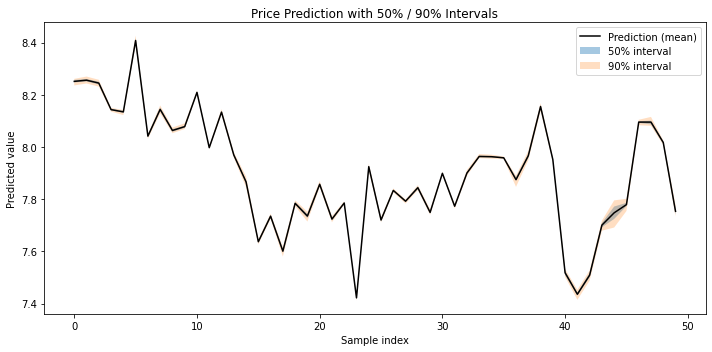

In [88]:
plot_prediction_intervals(
    price_pred_mean, price_p25, price_p75, price_p05, price_p95,
    title="Price Prediction with 50% / 90% Intervals"
)

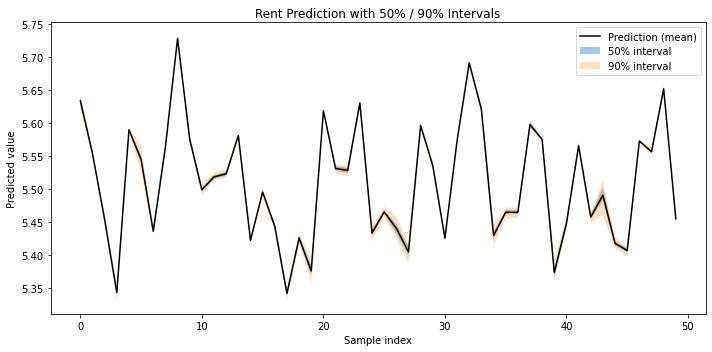

In [89]:
plot_prediction_intervals(
    rent_pred_mean, rent_p25, rent_p75, rent_p05, rent_p95,
    title="Rent Prediction with 50% / 90% Intervals"
)


In [90]:
def interval_stats(mean, p05, p95, p25, p75, name="Price"):
    width90 = (p95 - p05)
    width50 = (p75 - p25)
    stat = {
        f"{name}_width90_mean": float(np.mean(width90)),
        f"{name}_width90_p50": float(np.percentile(width90, 50)),
        f"{name}_width90_p90": float(np.percentile(width90, 90)),
        f"{name}_width50_mean": float(np.mean(width50)),
        f"{name}_width50_p50": float(np.percentile(width50, 50)),
        f"{name}_width50_p90": float(np.percentile(width50, 90)),
    }
    return stat

In [91]:
price_interval_stat = interval_stats(price_pred_mean, price_p05, price_p95, price_p25, price_p75, name="Price")
rent_interval_stat  = interval_stats(rent_pred_mean,  rent_p05,  rent_p95,  rent_p25,  rent_p75,  name="Rent")


In [92]:
stat_df = pd.DataFrame([price_interval_stat, rent_interval_stat]).T
stat_df.columns = ["Price", "Rent"]
print(stat_df)


                       Price      Rent
Price_width90_mean  0.028675       NaN
Price_width90_p50   0.023922       NaN
Price_width90_p90   0.048557       NaN
Price_width50_mean  0.011966       NaN
Price_width50_p50   0.009887       NaN
Price_width50_p90   0.020509       NaN
Rent_width90_mean        NaN  0.019140
Rent_width90_p50         NaN  0.016013
Rent_width90_p90         NaN  0.032848
Rent_width50_mean        NaN  0.007966
Rent_width50_p50         NaN  0.006544
Rent_width50_p90         NaN  0.013745


In [93]:
stat_path = os.path.join(OUT_DIR, "interval_width_stats.csv")
stat_df.to_csv(stat_path)
print("✅ 已保存区间宽度统计：", stat_path)

✅ 已保存区间宽度统计： outputs/interval_width_stats.csv


In [94]:
def top_risky_ids(test_ids, mean, p05, p95, topk=20, name="Price"):
    width90 = p95 - p05
    df = pd.DataFrame({
        "ID": test_ids,
        f"{name}_pred_mean": mean,
        f"{name}_p05": p05,
        f"{name}_p95": p95,
        f"{name}_width90": width90
    }).sort_values(f"{name}_width90", ascending=False).head(topk)
    return df

In [95]:
top_price_risky = top_risky_ids(price_test["ID"].values, price_pred_mean, price_p05, price_p95, topk=20, name="Price")
top_rent_risky  = top_risky_ids(rent_test["ID"].values,  rent_pred_mean,  rent_p05,  rent_p95,  topk=20, name="Rent")

In [96]:
print(top_price_risky)
print(top_rent_risky)

            ID  Price_pred_mean  Price_p05  Price_p95  Price_width90
26032  1026032         7.881976   7.645925   8.046779       0.400854
6940   1006940         7.827768   7.725890   8.012090       0.286200
249    1000249         7.426040   7.294863   7.574106       0.279243
32475  1032475         7.337626   7.207565   7.455063       0.247498
17798  1017798         7.624106   7.510748   7.741473       0.230725
10705  1010705         7.372719   7.258114   7.469404       0.211290
21766  1021766         7.782949   7.632973   7.843937       0.210964
25624  1025624         7.939983   7.836109   8.041971       0.205862
24326  1024326         7.279105   7.187970   7.384496       0.196525
18642  1018642         7.828378   7.677732   7.873982       0.196249
24070  1024070         7.893007   7.761805   7.957853       0.196047
14014  1014014         7.620147   7.521297   7.716924       0.195627
24203  1024203         7.259270   7.171344   7.366612       0.195268
24202  1024202         7.259508   

In [97]:
top_price_risky.to_csv(os.path.join(OUT_DIR, "top20_risky_price_by_interval.csv"), index=False)
top_rent_risky.to_csv(os.path.join(OUT_DIR, "top20_risky_rent_by_interval.csv"), index=False)
print("✅ 已保存 Top20 风险样本表到 outputs/")

✅ 已保存 Top20 风险样本表到 outputs/
